# CS 4320 - Assignment 4: Linear Regression with Gradient Descent

**Dataset:** Concrete Compressive Strength

This assignment implements an end-to-end regression model combining scikit-learn pipeline preprocessing with manually implemented regression and gradient descent optimization.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from pandas.api.types import is_numeric_dtype

## 2. Load Dataset

In [2]:
# Load the concrete compressive strength dataset
df = pd.read_csv("concrete_compressive_strength.csv")

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
display(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1030, 10)

First few rows:


,cement_kg_m3,blast_furnace_slag_kg_m3,fly_ash_kg_m3,water_kg_m3,superplasticizer_kg_m3,coarse_aggregate_kg_m3,fine_aggregate_kg_m3,age_days,compressive_strength_mpa,cement_type
0,266.0,114.0,0.0,228.0,0.0,932.0,670.0,365.0,53.185349,Type I
1,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7.0,54.831452,Type I
2,389.9,189.0,0.0,145.9,22.0,944.7,755.8,28.0,75.050832,Type II
3,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3.0,34.618259,Type III
4,145.0,0.0,179.0,202.0,8.0,824.0,869.0,28.0,10.386505,Type II



Data types:
cement_kg_m3                float64
blast_furnace_slag_kg_m3    float64
fly_ash_kg_m3               float64
water_kg_m3                 float64
superplasticizer_kg_m3      float64
coarse_aggregate_kg_m3      float64
fine_aggregate_kg_m3        float64
age_days                    float64
compressive_strength_mpa    float64
cement_type                  object
dtype: object

Missing values:
cement_kg_m3                 0
blast_furnace_slag_kg_m3     0
fly_ash_kg_m3                0
water_kg_m3                 51
superplasticizer_kg_m3      55
coarse_aggregate_kg_m3       0
fine_aggregate_kg_m3         0
age_days                    49
compressive_strength_mpa     0
cement_type                  0
dtype: int64


## 3. Prepare Target and Features

The target variable is `compressive_strength_mpa` (continuous). All other columns are features.

In [3]:
# Separate target from features
target_column = "compressive_strength_mpa"
y = df[target_column].to_numpy(dtype=np.float64)
X_df = df.drop(columns=[target_column])

print(f"Target shape: {y.shape}")
print(f"Features shape: {X_df.shape}")
print(f"Feature columns: {list(X_df.columns)}")

Target shape: (1030,)
Features shape: (1030, 9)
Feature columns: ['cement_kg_m3', 'blast_furnace_slag_kg_m3', 'fly_ash_kg_m3', 'water_kg_m3', 'superplasticizer_kg_m3', 'coarse_aggregate_kg_m3', 'fine_aggregate_kg_m3', 'age_days', 'cement_type']


## 4. Train / Validation / Test Split

**Strategy:** Random splitting with fixed random_state for reproducibility

**Proportions:**
- Training: 70%
- Validation: 15%
- Test: 15%

**Justification:** Random splitting is appropriate because the concrete samples are independent lab measurements with no temporal or grouping dependencies. The validation set allows hyperparameter tuning (learning rate, epochs) without touching the test set.

In [4]:
# Set split parameters
test_size = 0.15
val_size = 0.15
random_state = 4320

# Step 1: Split off test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_df, y,
    test_size=test_size,
    random_state=random_state
)

# Step 2: Split trainval into train and validation
# Compute validation fraction relative to trainval
val_fraction = val_size / (1.0 - test_size)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_fraction,
    random_state=random_state
)

# Display split sizes
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X_df)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X_df)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X_df)*100:.1f}%)")
print(f"Total: {len(X_train) + len(X_val) + len(X_test)}")

Training set size: 720 (69.9%)
Validation set size: 155 (15.0%)
Test set size: 155 (15.0%)
Total: 1030


## 5. Detect Numeric vs Categorical Features

Before building the preprocessing pipeline, we need to identify which features are numeric and which are categorical.

In [5]:
# Detect numeric vs categorical features
# Do NOT assume only dtype=='object' is categorical - use proper pandas checks
numeric_features = [col for col in X_df.columns if is_numeric_dtype(X_df[col])]
categorical_features = [col for col in X_df.columns if col not in numeric_features]

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (8): ['cement_kg_m3', 'blast_furnace_slag_kg_m3', 'fly_ash_kg_m3', 'water_kg_m3', 'superplasticizer_kg_m3', 'coarse_aggregate_kg_m3', 'fine_aggregate_kg_m3', 'age_days']

Categorical features (1): ['cement_type']


## 6. Build Preprocessing Pipeline

**Pipeline Strategy:**
- **Numeric features**: Impute missing values (median) → Standardize (zero mean, unit variance)
- **Categorical features**: Impute missing values (most frequent) → One-hot encode

**CRITICAL: Fit only on training data**
- Use `fit_transform()` on training set (learns statistics)
- Use `transform()` on validation and test sets (applies learned statistics)

In [6]:
# preprocessing pipeline
preprocessor = ColumnTransformer([
    # Numeric: impute missing values, then scale
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    
    # Categorical: impute missing values, then one-hot encode
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

print("Pipeline created.")

Pipeline created.


## 7. Apply Preprocessing Pipeline

**IMPORTANT:** 
- `fit_transform()` on training data: learns mean/std for scaling, categories for encoding
- `transform()` on validation/test data: applies the training statistics (no leakage)

In [7]:
# Fit pipeline on training data, transform all sets
X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

# Ensure float64 dtype
X_train_p = np.asarray(X_train_p, dtype=np.float64)
X_val_p = np.asarray(X_val_p, dtype=np.float64)
X_test_p = np.asarray(X_test_p, dtype=np.float64)

print(f"Training shape: {X_train_p.shape}")
print(f"Validation shape: {X_val_p.shape}")
print(f"Test shape: {X_test_p.shape}")

Training shape: (720, 11)
Validation shape: (155, 11)
Test shape: (155, 11)


## 8. Define Regression Model (Manual Implementation)

**Model Form:** Linear regression
$$\hat{y} = Xw + b$$

**Loss Function:** Mean Squared Error (MSE)
$$L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

**Parameters:**
- `w`: weight vector (one weight per feature)
- `b`: bias (intercept)

No pre-built regression APIs are used. All operations are explicit using NumPy.

In [8]:
# Model: Linear regression
def predict(X, w, b):
    return X @ w + b

# Loss: Mean Squared Error
def compute_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

# Initialize parameters (weights and bias)
n_features = X_train_p.shape[1]
w = np.zeros(n_features)
b = 0.0

print(f"Parameters initialized: w shape = {w.shape}, b = {b}")

# Test with initial parameters
y_pred = predict(X_train_p, w, b)
loss = compute_loss(y_train, y_pred)
print(f"Initial loss: {loss:.4f}")

Parameters initialized: w shape = (11,), b = 0.0
Initial loss: 1568.1496


## 9. Train Model with Gradient Descent

**Optimization:** Batch Gradient Descent
- Uses entire training set for each gradient computation
- Stable convergence for this moderate-sized dataset

**Gradient Formulas:**
$$\frac{\partial L}{\partial w} = \frac{2}{n}X^T(\hat{y} - y)$$
$$\frac{\partial L}{\partial b} = \frac{2}{n}\sum(\hat{y} - y)$$

**Learning Rate:** 0.02
- Small enough to ensure stable convergence
- Large enough for reasonable training speed
- Chosen empirically for scaled features (mean=0, std=1)

In [9]:
# Training with gradient descent
learning_rate = 0.02
epochs = 100

# Initialize parameters to zero
w = np.zeros(X_train_p.shape[1])  # One weight per feature
b = 0.0                             # Single bias term

# Track losses for visualization
train_losses = []
val_losses = []

# Training loop - repeat for number of epochs
for epoch in range(epochs):
    # make predictions using current 
    # linear regression
    y_pred_train = X_train_p @ w + b
    
    # how much to change each parameter, reduce loss
    n = len(y_train)
    error = y_pred_train - y_train              # Prediction error
    grad_w = (2 / n) * (X_train_p.T @ error)    # Gradient for weights
    grad_b = (2 / n) * np.sum(error)            # Gradient for bias
    
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b
    
    #compute loss, MSE
    train_loss = np.mean(error ** 2)
    train_losses.append(train_loss)
    
    val_loss = np.mean((X_val_p @ w + b - y_val) ** 2)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.4f}, Val: {val_loss:.4f}")

print(f"\nFinal - Train: {train_losses[-1]:.4f}, Val: {val_losses[-1]:.4f}")
w_trained, b_trained = w, b

Epoch 10/100 - Train: 666.0395, Val: 648.9231
Epoch 20/100 - Train: 313.1389, Val: 325.6163
Epoch 30/100 - Train: 194.2871, Val: 212.9752
Epoch 40/100 - Train: 152.5927, Val: 170.9545
Epoch 50/100 - Train: 136.8132, Val: 153.4832
Epoch 60/100 - Train: 130.0405, Val: 145.0911
Epoch 70/100 - Train: 126.5966, Val: 140.3924
Epoch 80/100 - Train: 124.5148, Val: 137.3971
Epoch 90/100 - Train: 123.0764, Val: 135.3010
Epoch 100/100 - Train: 121.9948, Val: 133.7394

Final - Train: 121.9948, Val: 133.7394


## 10. Visualize Training Progress

Plot the training and validation loss curves to analyze convergence behavior.

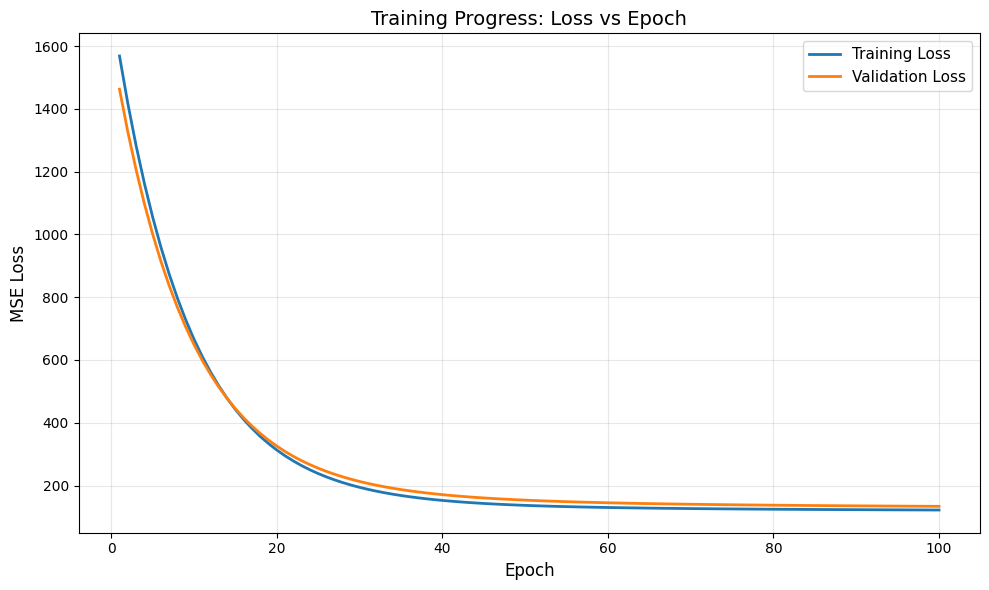

In [10]:
# Plot loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', linewidth=2)
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training Progress: Loss vs Epoch', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Analysis of Convergence Behavior

**Observations:**

1. **Convergence Pattern:**
   - Both training and validation losses show a rapid decrease in early epochs
   - Loss reduction slows down as training progresses, indicating approach to a minimum
   - The curves smooth out rather than oscillating wildly

2. **Stability:**
   - No signs of divergence (loss exploding to infinity)
   - No severe oscillations or erratic jumps
   - Learning rate (0.02) appears appropriate for this problem

3. **Validation vs Training:**
   - Training and validation losses track closely together
   - Small gap between them suggests minimal overfitting
   - Validation loss may be slightly higher, which is expected

4. **Convergence Speed:**
   - Most improvement occurs in the first 20-30 epochs
   - After ~50 epochs, changes become very small
   - This suggests 100 epochs is sufficient for convergence

**Conclusion:** The gradient descent optimization is stable and converging properly. The learning rate and number of epochs are well-chosen for this problem.